# 04 PantauPadi Multi-Horizon Forecast

Notebook ini digunakan untuk memprediksi risiko PantauPadi untuk beberapa bulan ke depan.

Konteks:
- Model sebelumnya memprediksi `risk_label_bulan_depan`, yaitu hanya **1 bulan ke depan**.
- Jika data terbaru adalah Maret 2026, maka prediksi 1 bulan ke depan = April 2026.
- Jika target yang ingin ditampilkan adalah Mei, Juni, Juli, dan Agustus 2026, maka horizon prediksinya adalah:
  - Mei = h+2 dari Maret
  - Juni = h+3 dari Maret
  - Juli = h+4 dari Maret
  - Agustus = h+5 dari Maret

Notebook ini memakai pendekatan **direct multi-horizon model**, yaitu membuat model terpisah untuk tiap horizon prediksi.

## Catatan Metodologi

Pendekatan yang dipakai:

```text
Fitur bulan t → prediksi risiko bulan t+h
```

Contoh:
- fitur Maret → prediksi Mei, jika h = 2
- fitur Maret → prediksi Juni, jika h = 3
- fitur Maret → prediksi Juli, jika h = 4
- fitur Maret → prediksi Agustus, jika h = 5

Keterbatasan:
- Semakin jauh horizon prediksi, performa model biasanya makin turun.
- Jika ingin prediksi yang lebih kuat, perlu menambahkan data prediksi iklim BMKG untuk bulan target, misalnya prediksi hujan, HTH, dan ATi/KAT.
- Hasil ini sebaiknya diposisikan sebagai **early warning projection**, bukan kepastian kondisi panen.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
from google.colab import drive
import os

# Menghubungkan Google Colab dengan Drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/collab/pantaupadi"

# Berpindah ke folder tersebut
os.chdir(path)

# Cek apakah file-file yang kamu butuhkan sudah terlihat
print("File di folder ini:")
print(os.listdir())

Mounted at /content/drive
File di folder ini:
['final_iklim.csv', 'padi_bulanan_bps', 'luas_panen', 'full_dataset.csv', 'produktivias.csv', 'mergepadi.csv', 'pantaupadi_feature_table_final.csv', 'pantaupadi_modeling_table_final.csv', 'pantaupadi_latest_risk_2026_final.csv', 'pantaupadi_feature_table_final_clean.csv', 'pantaupadi_modeling_table_final_clean.csv', 'pantaupadi_latest_risk_2026_final_clean.csv', 'eda', 'pantaupadi_prediksi_bulan_depan_2026.csv', 'pantaupadi_Feature.ipynb']


## 1. Load Feature Table

Gunakan file `pantaupadi_feature_table_final.csv`, bukan hanya `pantaupadi_modeling_table_final.csv`, karena kita perlu membuat target horizon baru dari `risk_label`.

In [ ]:
feature_path = 'pantaupadi_feature_table_final.csv'

if not os.path.exists(feature_path):
    try:
        from google.colab import files
        print("Upload file pantaupadi_feature_table_final.csv")
        uploaded = files.upload()
        if 'pantaupadi_feature_table_final.csv' in uploaded:
            feature_path = '/content/pantaupadi_feature_table_final.csv'
        else:
            feature_path = '/content/' + list(uploaded.keys())[0]
            print("Menggunakan file:", feature_path)
    except Exception as e:
        raise FileNotFoundError("File pantaupadi_feature_table_final.csv belum ditemukan.") from e

feature_table = pd.read_csv(feature_path)
feature_table['tanggal'] = pd.to_datetime(feature_table['tanggal'])
feature_table = feature_table.sort_values(['wilayah', 'tanggal']).copy()

print("Shape:", feature_table.shape)
feature_table.head()

Shape: (3069, 37)


,wilayah,tahun,bulan,hujan_mm,HTH_hari,hujan_normal_mm,rasio_hujan_terhadap_normal,sifat_hujan,KAT_value,KAT_normal,rasio_KAT_terhadap_normal,produksi_padi_bulanan,luas_panen_bulanan,tanggal,hujan_score,HTH_score,KAT_score,climate_score,freq_penurunan,volatilitas,historical_score,final_score,risk_label,risk_label_bulan_depan,final_score_bulan_depan,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,faktor_dominan,rekomendasi_aksi
0,BANGKALAN,2018,1,451.514587,0,334.360256,1.350384,AN,392.434481,371.607650,1.056056,4739.48,785.0,2018-01-01,0,0,0,0,0.428571,0.070316,2,2,low,medium,4.0,NaN,451.514587,NaN,1.350384,NaN,0.0,NaN,1.056056,NaN,0.000000,Sensitivitas historis wilayah,Pantau rutin; belum membutuhkan intervensi pri...
1,BANGKALAN,2018,2,202.027545,2,250.459204,0.806629,BN,395.880555,378.690230,1.045244,46564.49,7716.0,2018-02-01,2,0,0,2,0.428571,0.070316,2,4,medium,medium,3.0,451.514587,326.771066,1.350384,1.078506,0.0,1.0,1.056056,1.050650,0.0,1.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
2,BANGKALAN,2018,3,227.062383,1,243.218011,0.933576,N,395.380618,378.722207,1.043343,68927.85,11434.0,2018-03-01,0,0,1,1,0.428571,0.070316,2,3,medium,medium,5.0,202.027545,293.534838,0.806629,1.030196,2.0,1.0,1.045244,1.048214,2.0,1.000000,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
3,BANGKALAN,2018,4,97.913194,3,201.669351,0.485514,BN,376.930371,368.126476,1.021672,27021.81,4477.0,2018-04-01,2,0,1,3,0.428571,0.070316,2,5,medium,high,8.0,227.062383,175.667707,0.933576,0.741906,1.0,2.0,1.043343,1.036753,1.0,2.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
4,BANGKALAN,2018,5,30.727801,17,115.417852,0.266231,BN,313.243207,342.708690,0.910004,12847.50,2218.0,2018-05-01,2,2,2,6,0.428571,0.070316,2,8,high,high,8.0,97.913194,118.567793,0.485514,0.561773,3.0,7.0,1.021672,0.991673,3.0,3.333333,"Curah hujan bawah normal, HTH panjang, Keterse...","Prioritaskan pemantauan lapangan, cek irigasi/..."


## 2. Membuat Target Multi-Horizon

Jika data terbaru adalah Maret 2026 dan targetnya Mei–Agustus 2026:

| Bulan target | Horizon dari Maret |
|---|---:|
| Mei | h+2 |
| Juni | h+3 |
| Juli | h+4 |
| Agustus | h+5 |

In [ ]:
horizon_map = {
    2: 'Mei 2026',
    3: 'Juni 2026',
    4: 'Juli 2026',
    5: 'Agustus 2026'
}

for h in horizon_map:
    feature_table[f'risk_label_h{h}'] = feature_table.groupby('wilayah')['risk_label'].shift(-h)

feature_table[['wilayah', 'tahun', 'bulan', 'risk_label', 'risk_label_h2', 'risk_label_h3', 'risk_label_h4', 'risk_label_h5']].head(15)

,wilayah,tahun,bulan,risk_label,risk_label_h2,risk_label_h3,risk_label_h4,risk_label_h5
0,BANGKALAN,2018,1,low,medium,medium,high,high
1,BANGKALAN,2018,2,medium,medium,high,high,high
2,BANGKALAN,2018,3,medium,high,high,high,medium
3,BANGKALAN,2018,4,medium,high,high,medium,high
4,BANGKALAN,2018,5,high,high,medium,high,high
5,BANGKALAN,2018,6,high,medium,high,high,medium
6,BANGKALAN,2018,7,high,high,high,medium,low
7,BANGKALAN,2018,8,medium,high,medium,low,low
8,BANGKALAN,2018,9,high,medium,low,low,medium
9,BANGKALAN,2018,10,high,low,low,medium,medium


## 3. Menentukan Fitur Input

Fitur input memakai indikator bulan berjalan, fitur historis wilayah, serta lag/rolling.

In [ ]:
numeric_features = [
    'bulan',
    'hujan_mm',
    'rasio_hujan_terhadap_normal',
    'HTH_hari',
    'rasio_KAT_terhadap_normal',
    'hujan_score',
    'HTH_score',
    'KAT_score',
    'climate_score',
    'historical_score',
    'freq_penurunan',
    'volatilitas',
    'hujan_mm_lag1',
    'hujan_mm_roll3',
    'rasio_hujan_terhadap_normal_lag1',
    'rasio_hujan_terhadap_normal_roll3',
    'HTH_hari_lag1',
    'HTH_hari_roll3',
    'rasio_KAT_terhadap_normal_lag1',
    'rasio_KAT_terhadap_normal_roll3',
    'climate_score_lag1',
    'climate_score_roll3'
]

categorical_features = [
    'wilayah',
    'sifat_hujan'
]

features = numeric_features + categorical_features

missing_cols = [col for col in features if col not in feature_table.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut belum ada: {missing_cols}")

feature_table[features].head()

,bulan,hujan_mm,rasio_hujan_terhadap_normal,HTH_hari,rasio_KAT_terhadap_normal,hujan_score,HTH_score,KAT_score,climate_score,historical_score,freq_penurunan,volatilitas,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,wilayah,sifat_hujan
0,1,451.514587,1.350384,0,1.056056,0,0,0,0,2,0.428571,0.070316,NaN,451.514587,NaN,1.350384,NaN,0.0,NaN,1.056056,NaN,0.000000,BANGKALAN,AN
1,2,202.027545,0.806629,2,1.045244,2,0,0,2,2,0.428571,0.070316,451.514587,326.771066,1.350384,1.078506,0.0,1.0,1.056056,1.050650,0.0,1.000000,BANGKALAN,BN
2,3,227.062383,0.933576,1,1.043343,0,0,1,1,2,0.428571,0.070316,202.027545,293.534838,0.806629,1.030196,2.0,1.0,1.045244,1.048214,2.0,1.000000,BANGKALAN,N
3,4,97.913194,0.485514,3,1.021672,2,0,1,3,2,0.428571,0.070316,227.062383,175.667707,0.933576,0.741906,1.0,2.0,1.043343,1.036753,1.0,2.000000,BANGKALAN,BN
4,5,30.727801,0.266231,17,0.910004,2,2,2,6,2,0.428571,0.070316,97.913194,118.567793,0.485514,0.561773,3.0,7.0,1.021672,0.991673,3.0,3.333333,BANGKALAN,BN


## 4. Pipeline Model

Model yang dipakai adalah Logistic Regression karena pada modeling sebelumnya model ini lebih baik untuk mendeteksi kelas high dibanding Random Forest.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

def build_model():
    return Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])

## 5. Train dan Evaluasi Model Per Horizon

Evaluasi dilakukan dengan temporal split:
- Train: 2018–2024
- Test: 2025–2026 yang masih memiliki target historis

Catatan:
Untuk horizon yang lebih jauh, jumlah data test kelas high bisa sangat sedikit. Jika support high hanya 1 atau 0, metrik high perlu dibaca hati-hati.

In [ ]:
labels = ['low', 'medium', 'high']
evaluation_results = []
trained_models = {}

for h, month_name in horizon_map.items():
    target_col = f'risk_label_h{h}'

    data_h = feature_table.dropna(subset=[target_col]).copy()

    train_data = data_h[data_h['tahun'] <= 2024].copy()
    test_data = data_h[data_h['tahun'] >= 2025].copy()

    X_train = train_data[features]
    y_train = train_data[target_col]

    X_test = test_data[features]
    y_test = test_data[target_col]

    model = build_model()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=labels, zero_division=0
    )

    result = {
        'horizon': h,
        'bulan_prediksi': month_name,
        'train_n': len(train_data),
        'test_n': len(test_data),
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'recall_high': recall[2],
        'f1_high': f1[2],
        'support_high_test': support[2]
    }

    evaluation_results.append(result)
    trained_models[h] = model

    print("="*70)
    print(f"Horizon h+{h} → {month_name}")
    print("="*70)
    print("Train:", len(train_data), "| Test:", len(test_data))
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Recall High:", round(recall[2], 4), "| F1 High:", round(f1[2], 4), "| Support High:", support[2])
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=labels, zero_division=0))
    print("Confusion Matrix [low, medium, high]:")
    print(confusion_matrix(y_test, y_pred, labels=labels))
    print()

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.round(4)

Horizon h+2 → Mei 2026
Train: 2604 | Test: 403
Accuracy: 0.6898
Macro F1: 0.5714
Recall High: 0.6429 | F1 High: 0.24 | Support High: 14

Classification Report:
              precision    recall  f1-score   support

         low       0.79      0.77      0.78       180
      medium       0.78      0.62      0.69       209
        high       0.15      0.64      0.24        14

    accuracy                           0.69       403
   macro avg       0.57      0.68      0.57       403
weighted avg       0.76      0.69      0.72       403

Confusion Matrix [low, medium, high]:
[[139  31  10]
 [ 37 130  42]
 [  0   5   9]]

Horizon h+3 → Juni 2026
Train: 2604 | Test: 372
Accuracy: 0.5323
Macro F1: 0.4383
Recall High: 0.5714 | F1 High: 0.1301 | Support High: 14

Classification Report:
              precision    recall  f1-score   support

         low       0.74      0.79      0.76       167
      medium       0.69      0.30      0.42       191
        high       0.07      0.57      0.13     

,horizon,bulan_prediksi,train_n,test_n,accuracy,macro_f1,recall_high,f1_high,support_high_test
0,2,Mei 2026,2604,403,0.6898,0.5714,0.6429,0.2400,14
1,3,Juni 2026,2604,372,0.5323,0.4383,0.5714,0.1301,14
2,4,Juli 2026,2604,341,0.4927,0.3650,1.0000,0.0169,1
3,5,Agustus 2026,2604,310,0.5032,0.3793,1.0000,0.0192,1


## 6. Prediksi Mei–Agustus 2026

Data terbaru yang tersedia adalah bulan terakhir pada tahun 2026. Jika file terbaru berisi Januari–Maret 2026, maka model akan memakai baris Maret 2026 sebagai input untuk memprediksi Mei–Agustus.

In [ ]:
latest_year = feature_table['tahun'].max()
latest_month = feature_table[feature_table['tahun'] == latest_year]['bulan'].max()

latest_base = feature_table[
    (feature_table['tahun'] == latest_year) &
    (feature_table['bulan'] == latest_month)
].copy()

print("Data terbaru yang dipakai sebagai basis prediksi:")
print("Tahun:", latest_year, "| Bulan:", latest_month)
print("Jumlah wilayah:", latest_base['wilayah'].nunique())

latest_base[['wilayah', 'tahun', 'bulan', 'risk_label', 'final_score', 'climate_score', 'historical_score']].head()

Data terbaru yang dipakai sebagai basis prediksi:
Tahun: 2026 | Bulan: 3
Jumlah wilayah: 31


,wilayah,tahun,bulan,risk_label,final_score,climate_score,historical_score
98,BANGKALAN,2026,3,medium,3,1,2
197,BANYUWANGI,2026,3,medium,4,2,2
296,BATU,2026,3,medium,3,1,2
395,BLITAR,2026,3,medium,3,1,2
494,BOJONEGORO,2026,3,low,2,1,1


In [ ]:
forecast_rows = []

for h, month_name in horizon_map.items():
    model = trained_models[h]

    temp = latest_base.copy()
    temp['bulan_prediksi'] = month_name
    temp['horizon_bulan'] = h
    temp['prediksi_risk_label'] = model.predict(temp[features])

    output_cols = [
        'wilayah',
        'tahun',
        'bulan',
        'bulan_prediksi',
        'horizon_bulan',
        'risk_label',
        'final_score',
        'climate_score',
        'historical_score',
        'sifat_hujan',
        'HTH_hari',
        'rasio_KAT_terhadap_normal',
        'faktor_dominan',
        'rekomendasi_aksi',
        'prediksi_risk_label'
    ]

    available_cols = [col for col in output_cols if col in temp.columns]
    forecast_rows.append(temp[available_cols])

forecast_4bulan = pd.concat(forecast_rows, ignore_index=True)

forecast_4bulan.head(20)

,wilayah,tahun,bulan,bulan_prediksi,horizon_bulan,risk_label,final_score,climate_score,historical_score,sifat_hujan,HTH_hari,rasio_KAT_terhadap_normal,faktor_dominan,rekomendasi_aksi,prediksi_risk_label
0,BANGKALAN,2026,3,Mei 2026,2,medium,3,1,2,N,3,0.967354,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
1,BANYUWANGI,2026,3,Mei 2026,2,medium,4,2,2,N,4,1.030853,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
2,BATU,2026,3,Mei 2026,2,medium,3,1,2,AN,3,0.965766,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
3,BLITAR,2026,3,Mei 2026,2,medium,3,1,2,N,3,1.016676,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
4,BOJONEGORO,2026,3,Mei 2026,2,low,2,1,1,N,1,0.982019,"Ketersediaan air rendah, Sensitivitas historis...",Pantau rutin; belum membutuhkan intervensi pri...,low
5,BONDOWOSO,2026,3,Mei 2026,2,low,1,1,0,AN,4,1.050922,HTH panjang,Pantau rutin; belum membutuhkan intervensi pri...,low
6,GRESIK,2026,3,Mei 2026,2,medium,3,1,2,N,1,0.993438,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
7,JEMBER,2026,3,Mei 2026,2,low,2,2,0,N,6,1.039947,"HTH panjang, Ketersediaan air rendah",Pantau rutin; belum membutuhkan intervensi pri...,low
8,JOMBANG,2026,3,Mei 2026,2,low,1,1,0,N,2,0.991928,Ketersediaan air rendah,Pantau rutin; belum membutuhkan intervensi pri...,low
9,KEDIRI,2026,3,Mei 2026,2,medium,3,1,2,N,2,1.002023,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium


## 7. Distribusi Prediksi per Bulan

Tabel ini membantu melihat berapa wilayah yang diprediksi low, medium, dan high untuk Mei–Agustus.

In [ ]:
forecast_distribution = pd.crosstab(
    forecast_4bulan['bulan_prediksi'],
    forecast_4bulan['prediksi_risk_label']
).reindex(index=list(horizon_map.values()), columns=labels).fillna(0).astype(int)

forecast_distribution

prediksi_risk_label,low,medium,high
bulan_prediksi,,,
Mei 2026,9,17,5
Juni 2026,5,2,24
Juli 2026,5,11,15
Agustus 2026,5,2,24


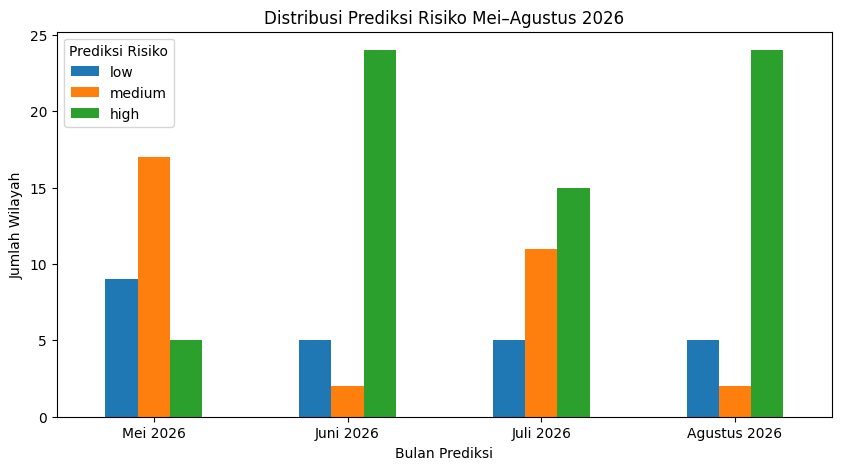

In [ ]:
forecast_distribution.plot(kind='bar', figsize=(10, 5))
plt.title('Distribusi Prediksi Risiko Mei–Agustus 2026')
plt.xlabel('Bulan Prediksi')
plt.ylabel('Jumlah Wilayah')
plt.xticks(rotation=0)
plt.legend(title='Prediksi Risiko')
plt.show()

## 8. Wilayah Prioritas Prediksi

Bagian ini menampilkan wilayah yang diprediksi high atau medium agar dapat diprioritaskan dalam dashboard.

In [ ]:
priority_forecast = forecast_4bulan[
    forecast_4bulan['prediksi_risk_label'].isin(['high', 'medium'])
].sort_values(
    ['bulan_prediksi', 'prediksi_risk_label', 'final_score'],
    ascending=[True, True, False]
)

priority_forecast.head(50)

,wilayah,tahun,bulan,bulan_prediksi,horizon_bulan,risk_label,final_score,climate_score,historical_score,sifat_hujan,HTH_hari,rasio_KAT_terhadap_normal,faktor_dominan,rekomendasi_aksi,prediksi_risk_label
94,BANYUWANGI,2026,3,Agustus 2026,5,medium,4,2,2,N,4,1.030853,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
112,PAMEKASAN,2026,3,Agustus 2026,5,medium,4,2,2,N,5,0.965501,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
123,TULUNGAGUNG,2026,3,Agustus 2026,5,medium,4,2,2,N,4,1.001448,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
93,BANGKALAN,2026,3,Agustus 2026,5,medium,3,1,2,N,3,0.967354,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
95,BATU,2026,3,Agustus 2026,5,medium,3,1,2,AN,3,0.965766,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
96,BLITAR,2026,3,Agustus 2026,5,medium,3,1,2,N,3,1.016676,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
99,GRESIK,2026,3,Agustus 2026,5,medium,3,1,2,N,1,0.993438,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
102,KEDIRI,2026,3,Agustus 2026,5,medium,3,1,2,N,2,1.002023,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
103,LAMONGAN,2026,3,Agustus 2026,5,medium,3,1,2,N,1,0.983374,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high
106,MAGETAN,2026,3,Agustus 2026,5,medium,3,1,2,N,3,1.010304,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,high


## 9. Export Hasil Prediksi 4 Bulan

File ini dapat dipakai untuk dashboard.

In [ ]:
forecast_4bulan.to_csv('pantaupadi_prediksi_mei_agustus_2026.csv', index=False)
evaluation_df.to_csv('pantaupadi_evaluasi_multi_horizon.csv', index=False)
forecast_distribution.to_csv('pantaupadi_distribusi_prediksi_mei_agustus_2026.csv')

print("File berhasil dibuat:")
print("- pantaupadi_prediksi_mei_agustus_2026.csv")
print("- pantaupadi_evaluasi_multi_horizon.csv")
print("- pantaupadi_distribusi_prediksi_mei_agustus_2026.csv")

File berhasil dibuat:
- pantaupadi_prediksi_mei_agustus_2026.csv
- pantaupadi_evaluasi_multi_horizon.csv
- pantaupadi_distribusi_prediksi_mei_agustus_2026.csv
